# Simulating Randomness and Random Numbers
     Instructor: Jarrian Vince G. Gojar

## Introduction

This notebook covers the fundamentals of computer simulation, focusing on the essential role of **random number generation**. We'll explore why and how simulations are used, the concept of pseudorandomness, and methods for generating random numbers following various distributions.

A simulation is a computer program that **imitates reality** to study situations and make decisions. We use them when:

* Actual experiments are **not feasible** or the system **doesn't exist**.
* The **cost** (money, time, danger) of real experiments is **prohibitive**.
* We need to **test alternatives** efficiently.

***
## Element of Chance: Pseudorandom Numbers

At the core of most simulations is **random number generation**. Since a computer follows deterministic instructions, the numbers generated are called **pseudorandom numbers**.

* **Pseudorandom:** Generated by an algorithm (an equation or set of rules), meaning the sequence is entirely predictable if the starting point (the **seed**) is known. They only *appear* to be random.
* **Monte Carlo Simulation:** Any simulation involving a probabilistic model and an element of chance is often referred to as a Monte Carlo simulation. 

### Multiplicative Linear Congruential Method (MLCM)

The MLCM is a common algorithm for generating a sequence of pseudorandom integers: 

$$\text{random}_n = (\text{multiplier} \times \text{random}_{n-1}) \bmod \text{modulus}, \text{ for } n > 0$$

A floating-point number $\text{rand}$ in $[0.0, 1.0)$ is then derived by dividing the integer by the modulus:

$$\text{rand} = \frac{\text{random}_n}{\text{modulus}}$$

In [1]:
def mlcm_generator(seed, multiplier, modulus, count):
    """Generates a sequence of pseudorandom integers and floating-point numbers."""
    random_n = seed
    integers = [random_n]
    
    for _ in range(count - 1):
        random_n = (multiplier * random_n) % modulus
        integers.append(random_n)
        
    # Convert to floating point numbers in [0.0, 1.0)
    floats = [i / modulus for i in integers]
    
    return integers, floats

seed = 10
multiplier = 7
modulus = 11
count = 10

integers, floats = mlcm_generator(seed, multiplier, modulus, count)

print(f"Seed: {seed}, Multiplier: {multiplier}, Modulus: {modulus}")
print(f"\nGenerated Integers: {integers}")
print(f"Generated Floats (First 5): {[round(f, 4) for f in floats[:5]]}")

Seed: 10, Multiplier: 7, Modulus: 11

Generated Integers: [10, 4, 6, 9, 8, 1, 7, 5, 2, 3]
Generated Floats (First 5): [0.9091, 0.3636, 0.5455, 0.8182, 0.7273]


***
## Transforming Uniform Random Numbers

The fundamental random number $\text{rand} \in [0.0, 1.0)$ needs to be scaled and shifted to fit the simulation's required range.

### 1. Random Floating Point Number $\text{min} \le r < \text{max}$

$$r = (\text{max} - \text{min}) \times \text{rand} + \text{min}$$

### 2. Random Integer $\text{min} \le n \le \text{max}$ (Inclusive)

$$n = \text{int}((\text{max} - \text{min} + 1) \times \text{rand} + \text{min})$$

In [2]:
import random

# Example 1: Floating Point between 20.0 and 26.3
min_f = 20.0
max_f = 26.3
rand_f = random.random() # Assumes a new rand in [0.0, 1.0)
r = (max_f - min_f) * rand_f + min_f
print(f"Floating Point ({min_f} to {max_f}): {r:.4f}")

# Example 2: Integer between 20 and 26 (inclusive)
min_i = 20
max_i = 26
rand_i = random.random() # Assumes a new rand in [0.0, 1.0)
n = int((max_i - min_i + 1) * rand_i + min_i)
print(f"Integer ({min_i} to {max_i} inclusive): {n}")

# Python's built-in equivalent
print(f"\nPython's built-in integer method: {random.randint(min_i, max_i)}")

Floating Point (20.0 to 26.3): 23.6164
Integer (20 to 26 inclusive): 26

Python's built-in integer method: 24


***
## Distributions: Discrete vs. Continuous

The **distribution** describes the portion of times each possible outcome occurs. 

### 1. Discrete Distribution (Unequal Probabilities)

To generate random events $e_1, e_2, \dots, e_n$ with specific probabilities $p_1, p_2, \dots, p_n$ (where $\sum p_i = 1$), we use the **cumulative probability** method. We map the uniform $\text{rand} \in [0, 1)$ to a specific event by checking which cumulative range it falls into.

**Example:** Simulating a coin toss where heads has a 70% chance ($p_H=0.7$) and tails has a 30% chance ($p_T=0.3$).
* If $\text{rand} < 0.7$ (i.e., $p_H$), return **Heads**.
* Else ($\text{rand} \ge 0.7$), return **Tails**.

In [3]:
def discrete_simulator(events_probs):
    """Generates a random event based on a dictionary of {event: probability}."""
    rand = random.random() # Uniform random number in [0.0, 1.0)
    cumulative_prob = 0.0
    
    for event, prob in events_probs.items():
        cumulative_prob += prob
        if rand < cumulative_prob:
            return event
    
    # Fallback (shouldn't happen if probabilities sum to 1)
    return list(events_probs.keys())[-1]
    
biased_coin = {"Heads": 0.7, "Tails": 0.3}
results = [discrete_simulator(biased_coin) for _ in range(10000)]

head_count = results.count("Heads")
tail_count = results.count("Tails")

print(f"Simulation of 10,000 biased tosses:")
print(f"Heads Count: {head_count} ({head_count/10000:.2f})")
print(f"Tails Count: {tail_count} ({tail_count/10000:.2f})")

Simulation of 10,000 biased tosses:
Heads Count: 6963 (0.70)
Tails Count: 3037 (0.30)


***
## Continuous Distributions: Advanced Methods

### 2. Normal (Gaussian) Distribution

This is the famous **Bell Curve**, defined by the mean ($\mu$) and standard deviation ($\sigma$). Generating numbers from this distribution often uses the **Box-Muller-Gauss Method**, which converts two uniform random numbers into two independent normally distributed numbers.

We use the `numpy` library in Python for efficiency, which internally uses algorithms like Box-Muller.

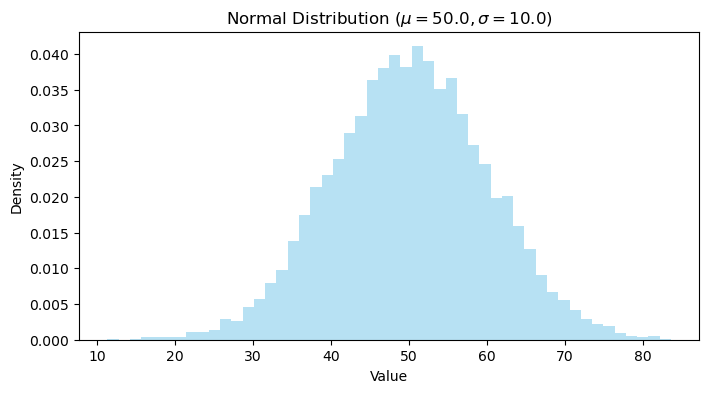

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the Normal Distribution
mu = 50.0   # Mean (e.g., average test score)
sigma = 10.0 # Standard Deviation (e.g., variability of scores)
num_samples = 10000

# Generate random numbers using a built-in method (based on Box-Muller)
normal_samples = np.random.normal(loc=mu, scale=sigma, size=num_samples)

# Plot the results to visualize the Bell Curve
plt.figure(figsize=(8, 4))
plt.hist(normal_samples, bins=50, density=True, alpha=0.6, color='skyblue')
plt.title(f'Normal Distribution ($\mu={mu}, \sigma={sigma}$)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

### Manual Implementation: Box-Muller-Gauss Method

While NumPy provides a built-in normal distribution generator, let's manually implement the **Box-Muller algorithm** to understand how it transforms uniform random numbers into normally distributed values.

**The Box-Muller Transformation:**

$$z_0 = \sqrt{-2 \ln(u_1)} \cos(2\pi u_2)$$
$$z_1 = \sqrt{-2 \ln(u_1)} \sin(2\pi u_2)$$

where $u_1, u_2$ are independent uniform random numbers in $[0, 1)$.

We compute:
- $b = \sqrt{-\ln(\text{rand})}$
- $a = $ uniform random in $[0, 2\pi)$
- Then: $b\sin(a) + \mu$ and $b\cos(a) + \mu$

To transform to a desired mean $\mu$ and standard deviation $\sigma$:
$$x = \mu + \sigma \times z$$

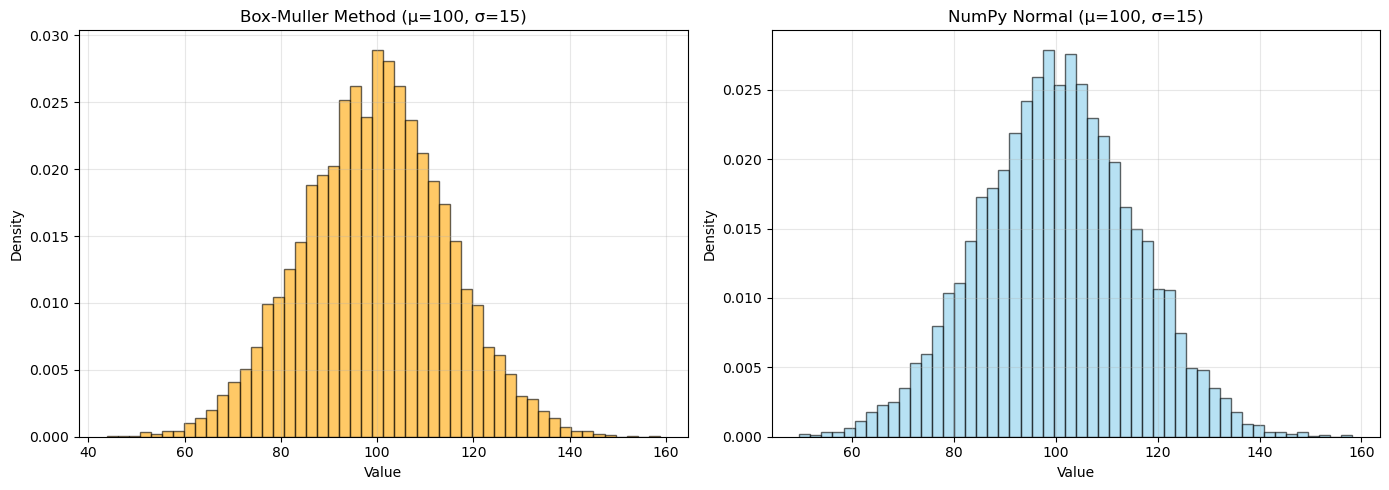

Box-Muller Implementation:
  Sample mean: 99.65 (Expected: 100)
  Sample std:  14.92 (Expected: 15)

NumPy Implementation:
  Sample mean: 100.28 (Expected: 100)
  Sample std:  15.14 (Expected: 15)


In [5]:
def box_muller_normal(mu=0, sigma=1):
    """Generate two independent normal random variables using Box-Muller."""
    # Generate two uniform random numbers
    u1 = random.random()
    u2 = random.random()
    
    # Avoid log(0)
    while u1 == 0:
        u1 = random.random()
    
    # Box-Muller transformation
    b = np.sqrt(-2 * np.log(u1))
    a = 2 * np.pi * u2
    
    z0 = b * np.cos(a)  # First standard normal variable
    z1 = b * np.sin(a)  # Second standard normal variable
    
    # Transform to desired mean and standard deviation
    x0 = mu + sigma * z0
    x1 = mu + sigma * z1
    
    return x0, x1

# Generate samples using Box-Muller
mu, sigma = 100, 15
samples_bm = []
for _ in range(5000):
    x0, x1 = box_muller_normal(mu, sigma)
    samples_bm.extend([x0, x1])

# Compare with NumPy's built-in
samples_numpy = np.random.normal(mu, sigma, 10000)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box-Muller implementation
axes[0].hist(samples_bm, bins=50, density=True, alpha=0.6, color='orange', edgecolor='black')
axes[0].set_title(f'Box-Muller Method (μ={mu}, σ={sigma})')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3)

# NumPy implementation
axes[1].hist(samples_numpy, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
axes[1].set_title(f'NumPy Normal (μ={mu}, σ={sigma})')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Box-Muller Implementation:")
print(f"  Sample mean: {np.mean(samples_bm):.2f} (Expected: {mu})")
print(f"  Sample std:  {np.std(samples_bm):.2f} (Expected: {sigma})")
print("\nNumPy Implementation:")
print(f"  Sample mean: {np.mean(samples_numpy):.2f} (Expected: {mu})")
print(f"  Sample std:  {np.std(samples_numpy):.2f} (Expected: {sigma})")

### 3. Exponential Distribution

Used to model the time between events. It is often generated using the **Inverse Transform Sampling** method, where you solve the inverse of the Cumulative Distribution Function (CDF). 

For the Exponential distribution, this results in the formula:

$$t = -\frac{1}{r} \ln(\text{rand})$$

where $r$ is the **rate** parameter (or $1/\lambda$, the mean time between events).

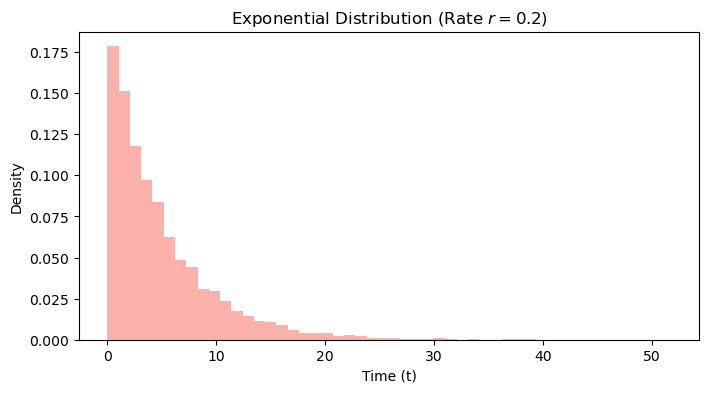

In [6]:
# Example: Simulating the time (t) between calls, where the average time is 5 minutes (Rate r = 1/5 = 0.2)
rate_r = 0.2  # The rate parameter
num_samples = 10000

# Implementation of the Inverse Transform Method
rand_samples = np.random.rand(num_samples)
t_samples = -np.log(rand_samples) / rate_r

plt.figure(figsize=(8, 4))
plt.hist(t_samples, bins=50, density=True, alpha=0.6, color='salmon')
plt.title(f'Exponential Distribution (Rate $r={rate_r}$)')
plt.xlabel('Time (t)')
plt.ylabel('Density')
plt.show()

***
## The Rejection Method

The **Rejection Method** is a general-purpose approach used when direct transformation methods (like the ones above) are not feasible for a complex distribution $f(x)$.

**Core Idea:**
1.  **Select a point** $x$ (from a uniform range $[a, b]$) and a random height $y$ (from $[0, \text{max}(f(x))])$.
2.  **Check:** If the height $y$ is below the curve, $y < f(x)$, **accept** $x$.
3.  **Reject:** If $y \ge f(x)$, **reject** $x$ and try again.

This simulates 'throwing darts' at the area under the curve and only keeping the darts that hit the target region, thus sampling the desired distribution.

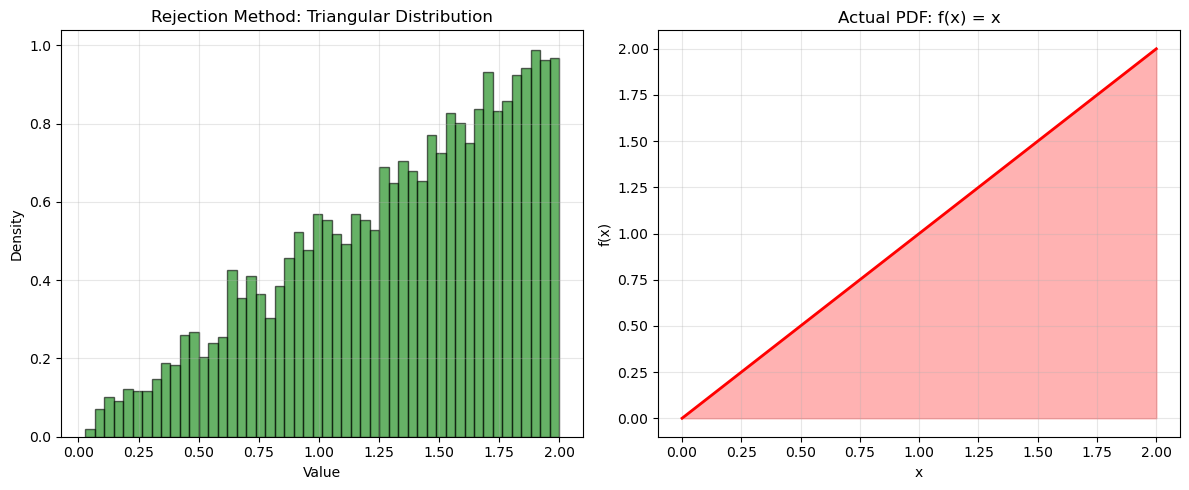

Generated 5000 samples using Rejection Method
Mean: 1.3308 (Expected: ~1.33)
Std Dev: 0.4746


In [7]:
def rejection_method(f, a, b, f_max, max_attempts=10000):
    """
    Generate a random number from distribution f(x) using the Rejection Method.
    
    Parameters:
    - f: The probability density function
    - a, b: Interval [a, b] for x values
    - f_max: Maximum value of f(x) in the interval
    - max_attempts: Maximum number of attempts before giving up
    """
    for _ in range(max_attempts):
        rand_interval = random.uniform(a, b)  # Random x in [a, b]
        rand_upper_bound = random.uniform(0, f_max)  # Random y in [0, f_max]
        
        if rand_upper_bound < f(rand_interval):  # Accept if point is under the curve
            return rand_interval
    
    raise ValueError("Failed to generate random number within max attempts")

# Example: Custom distribution f(x) = x for x in [0, 2]
def triangular_pdf(x):
    """Triangular distribution: f(x) = x for x in [0, 2]"""
    return x if 0 <= x <= 2 else 0

# Generate samples
samples = [rejection_method(triangular_pdf, 0, 2, 2) for _ in range(5000)]

# Visualize
plt.figure(figsize=(12, 5))

# Plot histogram
plt.subplot(1, 2, 1)
plt.hist(samples, bins=50, density=True, alpha=0.6, color='green', edgecolor='black')
plt.title('Rejection Method: Triangular Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)

# Plot the actual Probability Density Function (PDF)
x_vals = np.linspace(0, 2, 100)
y_vals = [triangular_pdf(x) for x in x_vals]
plt.subplot(1, 2, 2)
plt.plot(x_vals, y_vals, 'r-', linewidth=2)
plt.fill_between(x_vals, y_vals, alpha=0.3, color='red')
plt.title('Actual PDF: f(x) = x')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Generated {len(samples)} samples using Rejection Method")
print(f"Mean: {np.mean(samples):.4f} (Expected: ~1.33)")
print(f"Std Dev: {np.std(samples):.4f}")

***
## Monte Carlo Simulation: Estimating π

One of the most famous **Monte Carlo simulations** is estimating the value of π by "throwing darts" at a square containing an inscribed circle.

### The Method

- **Square** has side length $2r$, so area = $(2r)^2 = 4r^2$
- **Circle** has radius $r$, so area = $\pi r^2$
- The ratio of areas: $\frac{\pi r^2}{4r^2} = \frac{\pi}{4}$
- Therefore: $\pi \approx 4 \times \frac{\text{points in circle}}{\text{total points}}$

### Algorithm

1. Generate random points $(x, y)$ in the square $[-r, r] \times [-r, r]$
2. Check if each point is inside the circle: $x^2 + y^2 < r^2$
3. Calculate the ratio and multiply by 4 to estimate π

In [8]:
def estimate_pi(num_points):
    """Estimate π using Monte Carlo method."""
    radius = 1.0
    points_in_circle = 0
    
    for _ in range(num_points):
        # Generate random point in square [-radius, radius] × [-radius, radius]
        x = random.uniform(-radius, radius)
        y = random.uniform(-radius, radius)
        
        # Check if point is inside circle: x² + y² < r²
        if x**2 + y**2 < radius**2:
            points_in_circle += 1
    
    pi_estimate = 4 * points_in_circle / num_points
    return pi_estimate

# Test with increasing number of points
trials = [100, 1000, 10000, 100000, 1000000]
estimates = []
errors = []

print("Monte Carlo Estimation of π:")
print("=" * 55)
for n in trials:
    est = estimate_pi(n)
    estimates.append(est)
    error = abs(est - np.pi)
    errors.append(error)
    print(f"Points: {n:>8,} | π ≈ {est:.6f} | Error: {error:.6f}")

print(f"\nActual π: {np.pi:.10f}")

Monte Carlo Estimation of π:
Points:      100 | π ≈ 2.960000 | Error: 0.181593
Points:    1,000 | π ≈ 3.108000 | Error: 0.033593
Points:   10,000 | π ≈ 3.120000 | Error: 0.021593
Points:  100,000 | π ≈ 3.141520 | Error: 0.000073
Points: 1,000,000 | π ≈ 3.143628 | Error: 0.002035

Actual π: 3.1415926536


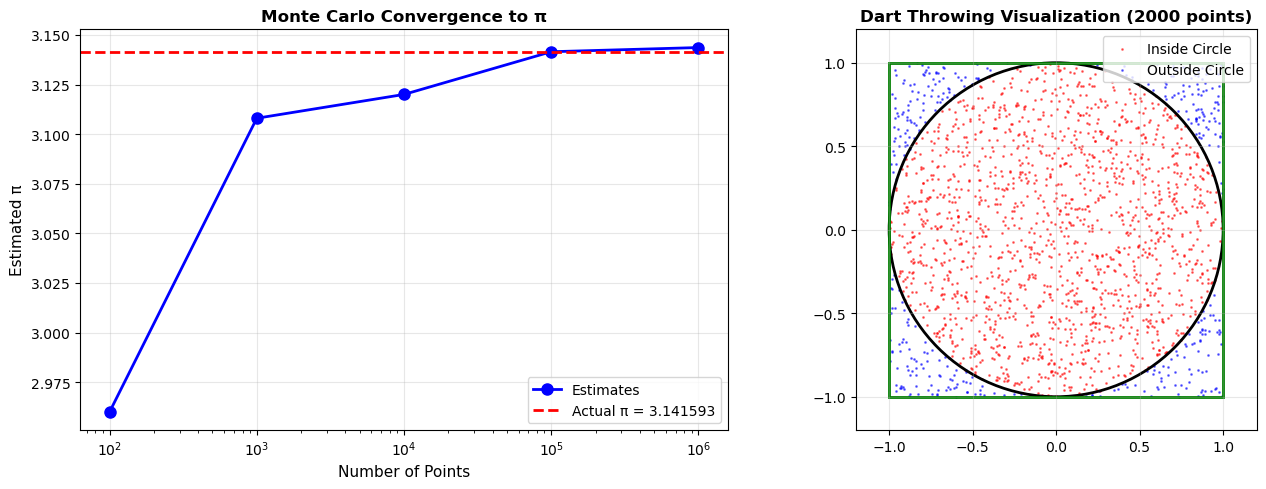


From visualization (2000 points): π ≈ 3.224000


In [9]:
from matplotlib.patches import Circle, Rectangle

# Visualize the convergence and dart-throwing process
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Estimates vs Number of Points
axes[0].plot(trials, estimates, 'bo-', label='Estimates', linewidth=2, markersize=8)
axes[0].axhline(y=np.pi, color='r', linestyle='--', linewidth=2, label=f'Actual π = {np.pi:.6f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Points', fontsize=11)
axes[0].set_ylabel('Estimated π', fontsize=11)
axes[0].set_title('Monte Carlo Convergence to π', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Visual representation of the dart-throwing
num_vis_points = 2000
radius = 1.0
x_points = [random.uniform(-radius, radius) for _ in range(num_vis_points)]
y_points = [random.uniform(-radius, radius) for _ in range(num_vis_points)]

# Classify points
inside = [(x, y) for x, y in zip(x_points, y_points) if x**2 + y**2 < radius**2]
outside = [(x, y) for x, y in zip(x_points, y_points) if x**2 + y**2 >= radius**2]

# Plot
if inside:
    axes[1].scatter(*zip(*inside), c='red', s=1, alpha=0.5, label='Inside Circle')
if outside:
    axes[1].scatter(*zip(*outside), c='blue', s=1, alpha=0.5, label='Outside Circle')

# Draw circle
circle = Circle((0, 0), radius, fill=False, color='black', linewidth=2)
axes[1].add_patch(circle)

# Draw square
square = Rectangle((-radius, -radius), 2*radius, 2*radius, 
                       fill=False, color='green', linewidth=2)
axes[1].add_patch(square)

axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[1].set_aspect('equal')
axes[1].set_title(f'Dart Throwing Visualization ({num_vis_points} points)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pi_from_vis = 4 * len(inside) / num_vis_points
print(f"\nFrom visualization ({num_vis_points} points): π ≈ {pi_from_vis:.6f}")

***
## Comparing Different Distributions

Let's visualize the four main distribution types side-by-side to understand their characteristics:
1. **Uniform** - Equal probability across the entire range
2. **Normal (Gaussian)** - Bell curve, most common in nature
3. **Exponential** - Models time between events in Poisson processes
4. **Discrete** - Specific outcomes with defined probabilities (e.g., dice roll)

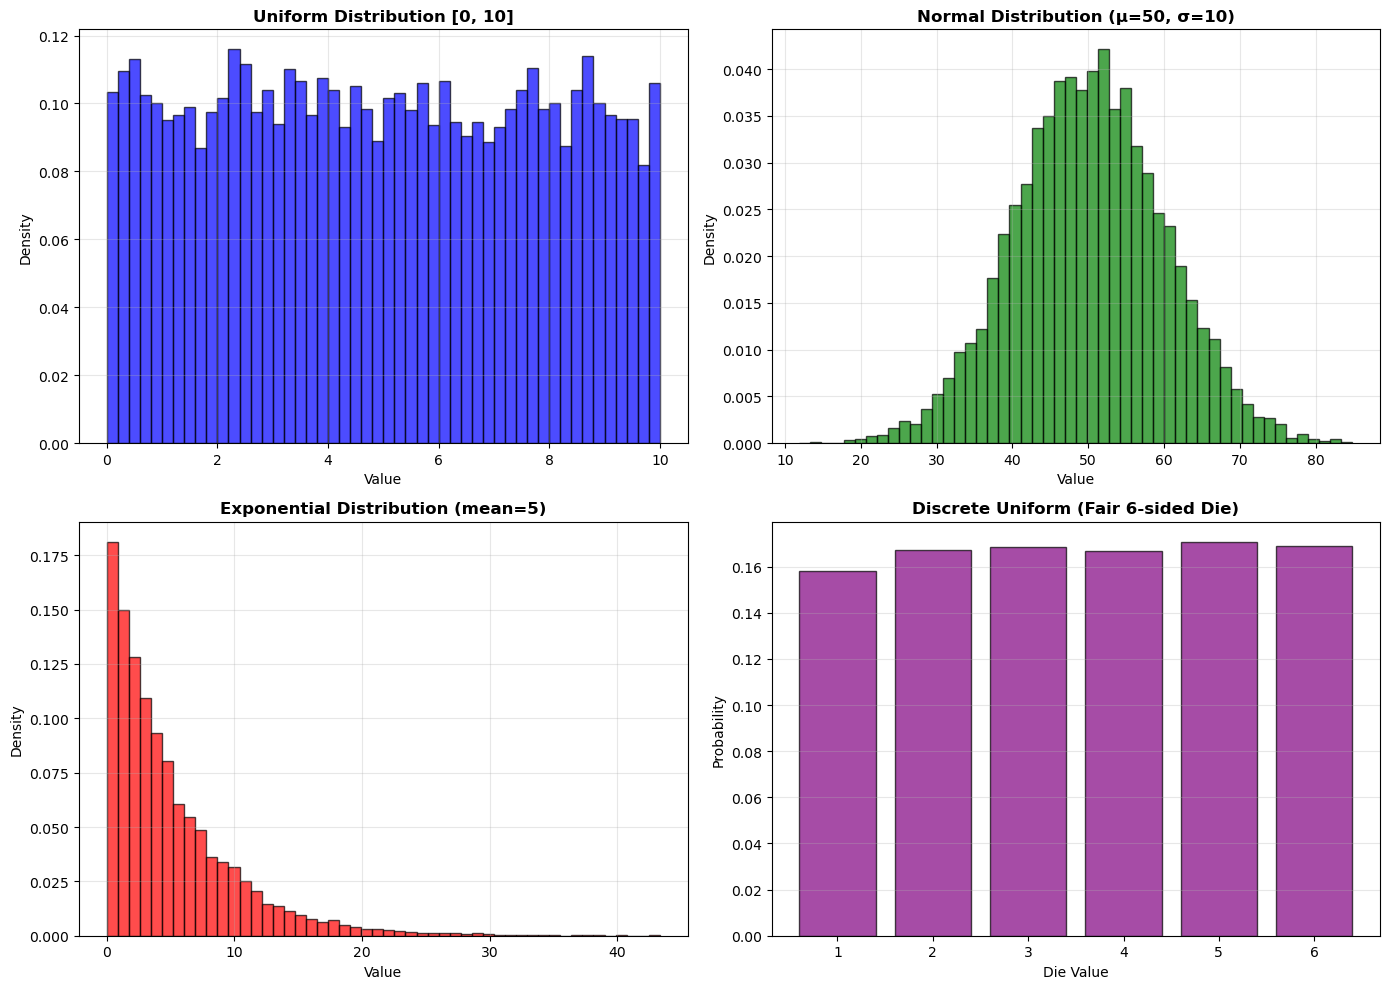

Distribution Statistics (10,000 samples):
Uniform:      Mean = 4.95, Std = 2.89
Normal:       Mean = 50.10, Std = 9.93
Exponential:  Mean = 5.06, Std = 5.02
Discrete:     Mean = 3.53, Std = 1.70


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Uniform Distribution
uniform_samples = np.random.uniform(0, 10, 10000)
axes[0, 0].hist(uniform_samples, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('Uniform Distribution [0, 10]', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].grid(True, alpha=0.3)

# 2. Normal Distribution
normal_samples = np.random.normal(50, 10, 10000)
axes[0, 1].hist(normal_samples, bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_title('Normal Distribution (μ=50, σ=10)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].grid(True, alpha=0.3)

# 3. Exponential Distribution
exponential_samples = np.random.exponential(5, 10000)
axes[1, 0].hist(exponential_samples, bins=50, density=True, alpha=0.7, color='red', edgecolor='black')
axes[1, 0].set_title('Exponential Distribution (mean=5)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, alpha=0.3)

# 4. Discrete Distribution (Fair Dice)
dice_rolls = [random.randint(1, 6) for _ in range(10000)]
axes[1, 1].hist(dice_rolls, bins=np.arange(0.5, 7.5, 1), density=True, 
                alpha=0.7, color='purple', edgecolor='black', rwidth=0.8)
axes[1, 1].set_title('Discrete Uniform (Fair 6-sided Die)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Die Value')
axes[1, 1].set_ylabel('Probability')
axes[1, 1].set_xticks(range(1, 7))
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics
print("Distribution Statistics (10,000 samples):")
print("=" * 60)
print(f"Uniform:      Mean = {np.mean(uniform_samples):.2f}, Std = {np.std(uniform_samples):.2f}")
print(f"Normal:       Mean = {np.mean(normal_samples):.2f}, Std = {np.std(normal_samples):.2f}")
print(f"Exponential:  Mean = {np.mean(exponential_samples):.2f}, Std = {np.std(exponential_samples):.2f}")
print(f"Discrete:     Mean = {np.mean(dice_rolls):.2f}, Std = {np.std(dice_rolls):.2f}")

***
## Summary and Key Takeaways

### Random Number Generation Methods

| Distribution | Generation Method | Formula/Algorithm |
|--------------|-------------------|-------------------|
| **Uniform** | Direct scaling | $r = (\text{max} - \text{min}) \times \text{rand} + \text{min}$ |
| **Discrete** | Cumulative probability | Map $\text{rand}$ to cumulative probability ranges |
| **Normal** | Box-Muller-Gauss | $b\sin(a) + \mu$ where $b = \sqrt{-\ln(\text{rand})}$, $a \in [0, 2\pi)$ |
| **Exponential** | Inverse Transform | $t = -\frac{1}{r}\ln(\text{rand})$ |
| **Arbitrary** | Rejection Method | Accept $x$ if $\text{rand} < f(x)$ |

### Important Concepts

1. **Pseudorandom Numbers**: Generated by deterministic algorithms, appear random but are predictable with known seed
2. **Seed**: Initial value that determines the entire sequence (critical for reproducibility)
3. **Monte Carlo Simulation**: Probabilistic model involving an element of chance
4. **Distribution**: Describes the frequency of each outcome over many trials
5. **Multiplicative Linear Congruential Method**: $\text{random}_n = (\text{multiplier} \times \text{random}_{n-1}) \bmod \text{modulus}$

### When to Use Computer Simulations

**✓ Use when:**
- Actual experiments are **not feasible** or the system **doesn't exist**
- **Cost** (money, time, danger) of real experiments is **prohibitive**
- Need to **test multiple alternatives** efficiently

**✗ Disadvantages:**
- The simulation may be **expensive** in time or money to develop
- Impossible to test every alternative → can provide **good solutions but not necessarily the best**
- Results may be **difficult to verify** because often we do not have real-world data
- Cannot be sure we **understand what the simulation actually does**
- When probabilistic with element of chance, we should be **careful of our conclusions**

***
## Reference

A.B. Shiflet, G.W. Shiflet, *Introduction to Computational Science*, 2nd Edition, 2014, Princeton University Press.

---